# **HCC1806 - SmartSeq**

## **Introduction**:

In this file, we will perform the Exploratory Data Analysis and Data Pre-Processing of the HCC1806 cell line with the SmartSeq technology.




### **Structure of the file**

1. **Introduction**
   * Structure of the File
   * Python Libraries
2. **Exploratory Data Analysis (EDA)**
   * Metadata File
   * Unfiltered File
      * General Information
      * Missing Values
      * Duplicate Genes
      * Sample Correlation
      * Outliers
      * Sparsity
      * Distribution of the Data
3. **Data Pre-Processing**
   * Filtering
      * Duplicate Genes
      * Quality Control
   * Data Transformation
   * Normalization
   * Feature Selection

### **Python Libraries**

In [1]:
import sys
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(color_codes=True)
from scipy.stats import kurtosis, skew

# **Exploratory Data Analysis**:

## **Metadata File**

First, we read the file with the metadata:

In [3]:
df_meta = pd.read_csv("/Users/bianca/Desktop/HCC1806_SmartS_MetaData.tsv",delimiter="\t",engine='python',index_col=0)
print("DataFrame dimensions:", np.shape(df_meta))
print("DataFrame indexes:\n", df_meta.index)

DataFrame dimensions: (243, 8)
DataFrame indexes:
 Index(['output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam',
       'output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam',
       'output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam',
       'output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam',
       'output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam',
       'output.STAR.PCRPlate1A4_Hypoxia_S8_Aligned.sortedByCoord.out.bam',
       'output.STAR.PCRPlate1A5_Hypoxia_S108_Aligned.sortedByCoord.out.bam',
       'output.STAR.PCRPlate1A6_Hypoxia_S11_Aligned.sortedByCoord.out.bam',
       'output.STAR.PCRPlate1A7_Normoxia_S113_Aligned.sortedByCoord.out.bam',
       'output.STAR.PCRPlate1A8_Normoxia_S119_Aligned.sortedByCoord.out.bam',
       ...
       'output.STAR.PCRPlate4G12_Normoxia_S243_Aligned.sortedByCoord.out.bam',
       'output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam',
       'outpu

In [4]:
df_meta.head(5)   

,Cell Line,PCR Plate,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments
Filename,,,,,,,,
output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam,HCC1806,1,A10,Normo,24,S123,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam,HCC1806,1,A12,Normo,24,S26,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam,HCC1806,1,A1,Hypo,24,S97,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam,HCC1806,1,A2,Hypo,24,S104,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam,HCC1806,1,A3,Hypo,24,S4,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"


File is composed of 243 rows and 8 columns, where each row represents a single cell/sample. Accordingly, the columns are:
* **Cell Line**: Type of tumor cell. In this case HCC1806, a human basal-like triple-negative breast cancer cell line.

* **PCR Plate**: Type of plate used to run PCR reactions for the sample.

* **Pos**: Position of the cell inside the plate.

* **Condition**: Indicates whether a sample was *normoxic* or *hypoxic*.

* **Hours**: Number of hours of observation.

* **Cell name**: Indicates the unique name/ID of each cell. 

* **Preprocessing Tag**: indicates the preprocessing. It is the same for all values. 
    
    - *Aligned.sortedByCoord* refers to the fact that the reads (the RNA sequence from one fragment) have been organized based on the specific position on the genome.
    
    - *out.bam* indicates the output has been saved as a Binary Alignment Map file (BAM), namely a compressed version of a Sequence Alignment Map (SAM) file.

* **Processing Comments**: indicates additional information on the processing of the sample.

    - *STAR* indicates the type of alignment conducted.

    - *FeatureCounts* is just the name of the software used.


Check for duplicate cell names in metadafile

In [6]:
names = [i for i in df_meta['Cell name']]
assert len(names)==len(set(names))

In [7]:
df_meta.describe(include='all')

,Cell Line,PCR Plate,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments
count,243,243.000000,243,243,243.0,243,243,243
unique,1,NaN,91,2,NaN,243,1,1
top,HCC1806,NaN,A10,Hypo,NaN,S123,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
freq,243,NaN,4,126,NaN,1,243,243
mean,NaN,2.411523,NaN,NaN,24.0,NaN,NaN,NaN
std,NaN,1.081107,NaN,NaN,0.0,NaN,NaN,NaN
min,NaN,1.000000,NaN,NaN,24.0,NaN,NaN,NaN
25%,NaN,1.000000,NaN,NaN,24.0,NaN,NaN,NaN
50%,NaN,2.000000,NaN,NaN,24.0,NaN,NaN,NaN
75%,NaN,3.000000,NaN,NaN,24.0,NaN,NaN,NaN


Now, we count how many *Normoxic* and *Hypoxic* cells there are in our dataset. This is because we want a balanced dataset with respect to the two conditions as an imbalanced dataset could negatively affect the training phase and lead to a biased model.

Condition
Hypo     126
Normo    117
Name: count, dtype: int64


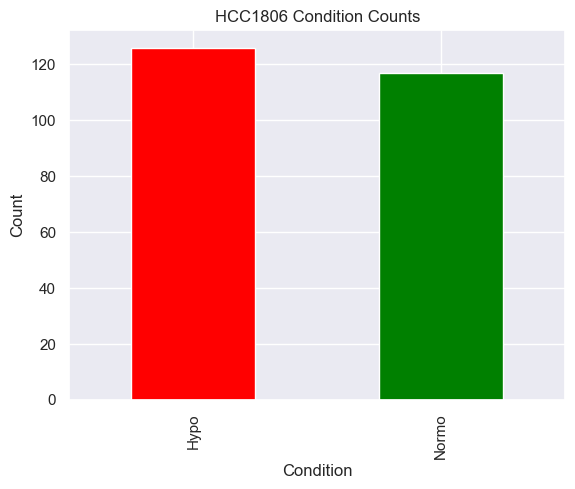

In [5]:
counts = df_meta["Condition"].value_counts()
print(counts)
counts.plot(kind = 'bar', color = ['red', 'green'])
plt.title("HCC1806 Condition Counts")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()

We can proceed with the analysis as they have a similar count.

Lastly, we check for missing values:

In [8]:
print(df_meta.isnull().sum())

Cell Line             0
PCR Plate             0
Pos                   0
Condition             0
Hours                 0
Cell name             0
PreprocessingTag      0
ProcessingComments    0
dtype: int64


## **Unfiltered File**


### **General Information**

Exploring first the unfiltered dataset in order to understand the issues of the dataset and its implications. This file is a matrix of counts where no filter nor normalization was applied. 

In [9]:
df = pd.read_csv("/Users/bianca/Desktop/HCC1806_SmartS_Unfiltered_Data.txt",delimiter="\ ",engine='python',index_col=0)
print("DataFrame dimensions:\n", np.shape(df))
print("\nColumn data types:\n", df.dtypes)
print("\nDataFrame indexes:\n", df.index)

DataFrame dimensions:
 (23396, 243)

Column data types:
 "output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam"    int64
"output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam"     int64
"output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam"       int64
"output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam"      int64
"output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam"        int64
                                                                          ...  
"output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam"    int64
"output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam"    int64
"output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam"      int64
"output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam"     int64
"output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam"     int64
Length: 243, dtype: object

DataFrame indexes:
 Index(['"WASH7P

File is composed of 23396 rows and 243 columns, where each column corresponds to a single cell/sample and each row a gene/feature. A zero entry indicates that that specific gene was not detected in that particular cell sample

In [10]:
numeric_columns = df.select_dtypes(include=[np.number]).columns
all_numeric = len(numeric_columns) == len(df.columns)
print(all_numeric)

True


All the data is numerical, of integer type. 


This DataFrame uses symbols to identify genes. Each human gene has one unique approved symbol, they start with a letter and can only contain uppercase Latin letters and Arabic numerals.

In [11]:
df.head(5)

,"""output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A4_Hypoxia_S8_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A5_Hypoxia_S108_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A6_Hypoxia_S11_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A7_Normoxia_S113_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A8_Normoxia_S119_Aligned.sortedByCoord.out.bam""",...,"""output.STAR.PCRPlate4G12_Normoxia_S243_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G2_Hypoxia_S198_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G7_Normoxia_S204_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam"""
"""WASH7P""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""CICP27""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""DDX11L17""",0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""WASH9P""",0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
"""OR4F29""",2,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


We transpose the original DataFrame to have the cells in the rows and the genes in the columns so as to facilitate future analysis. We will also remove the quotation marks in the names of the features and the samples to simplify our analysis. 

In [12]:
def remove_double_quotes(word):
    return word.replace('"', '')

In [13]:
df_t = df.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in df.columns})
df = df_t.T
df = df.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in df.columns})
print("Transposed DataFrame dimensions:", np.shape(df))
df.head(5)

Transposed DataFrame dimensions: (243, 23396)


,WASH7P,CICP27,DDX11L17,WASH9P,OR4F29,MTND1P23,MTND2P28,MTCO1P12,MTCO2P12,MTATP8P1,...,MT-TH,MT-TS2,MT-TL2,MT-ND5,MT-ND6,MT-TE,MT-CYB,MT-TT,MT-TP,MAFIP
output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam,0,0,0,0,2,250,54,1740,6,1,...,17,5,15,3852,900,22,4208,26,66,0
output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam,0,0,0,0,0,424,100,2340,5,1,...,49,29,36,7457,1439,43,6491,62,71,4
output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam,0,0,0,0,0,11,0,22,0,0,...,0,0,0,93,12,0,25,0,1,0
output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam,0,0,0,0,0,63,16,1020,3,0,...,43,17,8,1479,234,0,4819,11,3,7
output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam,0,0,0,0,0,27,3,303,0,0,...,0,0,3,303,33,0,310,4,9,0


Now, the DataFrame has 243 rows representing each cell/sample and 23396 columns representing the genes/features.

Next, we compute the summary statistics for each gene.

In [15]:
df.describe(include="all")

,WASH7P,CICP27,DDX11L17,WASH9P,OR4F29,MTND1P23,MTND2P28,MTCO1P12,MTCO2P12,MTATP8P1,...,MT-TH,MT-TS2,MT-TL2,MT-ND5,MT-ND6,MT-TE,MT-CYB,MT-TT,MT-TP,MAFIP
count,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,...,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,0.045267,0.119342,0.469136,0.255144,0.127572,117.930041,28.427984,904.308642,1.403292,0.378601,...,10.358025,5.930041,13.493827,2290.213992,386.901235,18.246914,2163.588477,20.613169,46.444444,3.897119
std,0.318195,0.594531,1.455282,0.818639,0.440910,103.038022,26.062662,654.520308,1.735003,0.747361,...,10.910199,7.040559,11.803967,1726.423259,309.276105,54.076514,1730.393947,22.224590,47.684223,4.736193
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,46.500000,8.000000,390.500000,0.000000,0.000000,...,2.000000,1.000000,4.000000,918.000000,138.500000,4.000000,947.500000,5.000000,14.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,94.000000,22.000000,790.000000,1.000000,0.000000,...,7.000000,4.000000,10.000000,1848.000000,320.000000,11.000000,1774.000000,14.000000,38.000000,2.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,157.000000,42.000000,1208.000000,2.000000,1.000000,...,14.000000,7.500000,20.000000,3172.000000,528.000000,20.000000,2927.000000,30.500000,64.500000,6.000000
max,3.000000,5.000000,12.000000,6.000000,4.000000,694.000000,120.000000,3569.000000,12.000000,4.000000,...,52.000000,43.000000,57.000000,8972.000000,1439.000000,804.000000,11383.000000,154.000000,409.000000,24.000000


This is a **Gene Expression Matrix**, where each entry signifies the *expression level* of that particular gene for that particular cell. Gene expression level is the amount of RNA produced from a gene in a cell, overall it indicates how active that gene is.

More specifically:

The fact that most genes have a *low* **mean** and a *zero* **median** reflects the idea that the majority of the features are weakly expressed throughout all the samples. Accordingly, it leads to a very **sparse** dataset, which is typical in single-cell RNA sequencing data.

Also, the *high* **standard deviation** comes from the **maxima** being much higher than the mean, which is consistent with the idea that some genes are highly expressed in a small subset of cells.

In [16]:
# Sum of expression per gene
gene_sums = df.sum(axis=0)

# Least expressed gene
min_gene = gene_sums.idxmin()
print("Gene with the least total expression:", min_gene)
print("Total expression:", gene_sums.min())

# Most expressed gene
max_gene = gene_sums.idxmax()
print("Gene with the most total expression:", max_gene)
print("Total expression:", gene_sums.max())

print("Global max is:", df.describe().loc["max"].max())
print("Global min is:", df.describe().loc["min"].min())

Gene with the least total expression: CICP3
Total expression: 2
Gene with the most total expression: ACTB
Total expression: 6582141
Global max is: 210944.0
Global min is: 0.0


### **Missing Values**

We proceed with a quick check to verify that the DataFrame has no missing values.

In [17]:
print("Count of missing values:", df.isna().sum().sum())

Count of missing values: 0


Also, we check that none of the columns or rows contain only 0 values.

In [18]:
zero_columns = []
for column in df.columns:
    if (df[column] == 0).all():
        zero_columns.append(column)
if zero_columns == []:
    print ("There are no columns full of 0")
## check rows all missing values 
zero_rows = []
for index, row in df.iterrows():
    if (row == 0).all():
        zero_rows.append(index)
if zero_rows == []:
    print("There are no rows full of 0")

There are no columns full of 0
There are no rows full of 0


### **Duplicate Genes**

We also want to see if there are genes that behave the same across all of the cells, seeking to identify redundant genes.

In [19]:
duplicate_data = df_t[df_t.duplicated()]
print("Number of duplicate genes:", duplicate_data.shape[0], "over", df_t.shape[0])
print("Percentage of duplicate genes:", (duplicate_data.shape[0] * 100) / (df_t.shape[0]), "%")

Number of duplicate genes: 54 over 23396
Percentage of duplicate genes: 0.2308086852453411 %


Since there exists duplicates, we want to investigate which genes are equal to each other via a correlation matrix. "1" marks the genes that behave identically.

In [20]:
duplicate_data.T.corr()

,"""ITGA10""","""GPA33""","""OR2M4""","""ZBTB45P2""","""RNY1P12""","""C4orf50""","""PCDHA8""","""PCDHGA3""","""PCDHGB3""","""PCDHGA7""",...,"""RNU6-826P""","""MSX2P1""","""MIR548AA2""","""KCNJ16""","""CD300A""","""ENPP7""","""DTNA""","""ALPK2""","""OR7G2""","""PLVAP"""
"""ITGA10""",1.000000,1.000000,0.495851,-0.010083,-0.008299,1.000000,0.004785,-0.049831,-0.049831,-0.049831,...,-0.008299,-0.008299,-0.009421,0.495851,1.000000,0.495851,1.000000,0.081755,0.495851,1.000000
"""GPA33""",1.000000,1.000000,0.495851,-0.010083,-0.008299,1.000000,0.004785,-0.049831,-0.049831,-0.049831,...,-0.008299,-0.008299,-0.009421,0.495851,1.000000,0.495851,1.000000,0.081755,0.495851,1.000000
"""OR2M4""",0.495851,0.495851,1.000000,-0.010083,-0.008299,0.495851,0.331596,-0.049831,-0.049831,-0.049831,...,-0.008299,-0.008299,-0.009421,-0.008299,0.495851,-0.008299,0.495851,-0.006540,-0.008299,0.495851
"""ZBTB45P2""",-0.010083,-0.010083,-0.010083,1.000000,-0.010083,-0.010083,-0.057440,-0.039036,-0.039036,-0.039036,...,-0.010083,-0.010083,-0.011447,-0.010083,-0.010083,-0.010083,-0.010083,0.335362,-0.010083,-0.010083
"""RNY1P12""",-0.008299,-0.008299,-0.008299,-0.010083,1.000000,-0.008299,-0.015460,0.082043,0.082043,0.082043,...,-0.008299,-0.008299,-0.009421,-0.008299,-0.008299,-0.008299,-0.008299,-0.006540,-0.008299,-0.008299
"""C4orf50""",1.000000,1.000000,0.495851,-0.010083,-0.008299,1.000000,0.004785,-0.049831,-0.049831,-0.049831,...,-0.008299,-0.008299,-0.009421,0.495851,1.000000,0.495851,1.000000,0.081755,0.495851,1.000000
"""PCDHA8""",0.004785,0.004785,0.331596,-0.057440,-0.015460,0.004785,1.000000,0.007687,0.007687,0.007687,...,-0.047274,-0.044382,0.003243,-0.018353,0.004785,-0.044382,0.004785,-0.036751,-0.044382,0.004785
"""PCDHGA3""",-0.049831,-0.049831,-0.049831,-0.039036,0.082043,-0.049831,0.007687,1.000000,1.000000,1.000000,...,-0.044411,0.022429,0.002903,-0.028153,-0.049831,-0.051637,-0.049831,-0.040696,-0.017314,-0.049831
"""PCDHGB3""",-0.049831,-0.049831,-0.049831,-0.039036,0.082043,-0.049831,0.007687,1.000000,1.000000,1.000000,...,-0.044411,0.022429,0.002903,-0.028153,-0.049831,-0.051637,-0.049831,-0.040696,-0.017314,-0.049831
"""PCDHGA7""",-0.049831,-0.049831,-0.049831,-0.039036,0.082043,-0.049831,0.007687,1.000000,1.000000,1.000000,...,-0.044411,0.022429,0.002903,-0.028153,-0.049831,-0.051637,-0.049831,-0.040696,-0.017314,-0.049831


Genes are expected to be correlated, and that is biologically meaningful. That is because, genes often work in networks. So, if one gene is active, others in the same process may be also active. Eliminating these genes reduces the dimensions of this data, improving the efficiency and helping prevent overfitting.

We make a note to remove the duplicate genes in the Data Pre-Processing section of this analysis.

### **Sample Correlation**

We check the correlation between gene expression profiles of the different cells (between samples) and visualize it using a heatmap.

For this analysis, we will use *Pearson's Correlation Coefficient*: a bivariate correlation coefficient that measures the linear relationship between two variables. It ranges from -1 to 1, where: 1 implies a perfect positive linear relationship, -1 a perfect negative linear relationship, and 0 no linear relationship between the variables.

Average correlation between cells:  0.4992953213403934
Minimum correlation between cells:  -0.00140935731921326


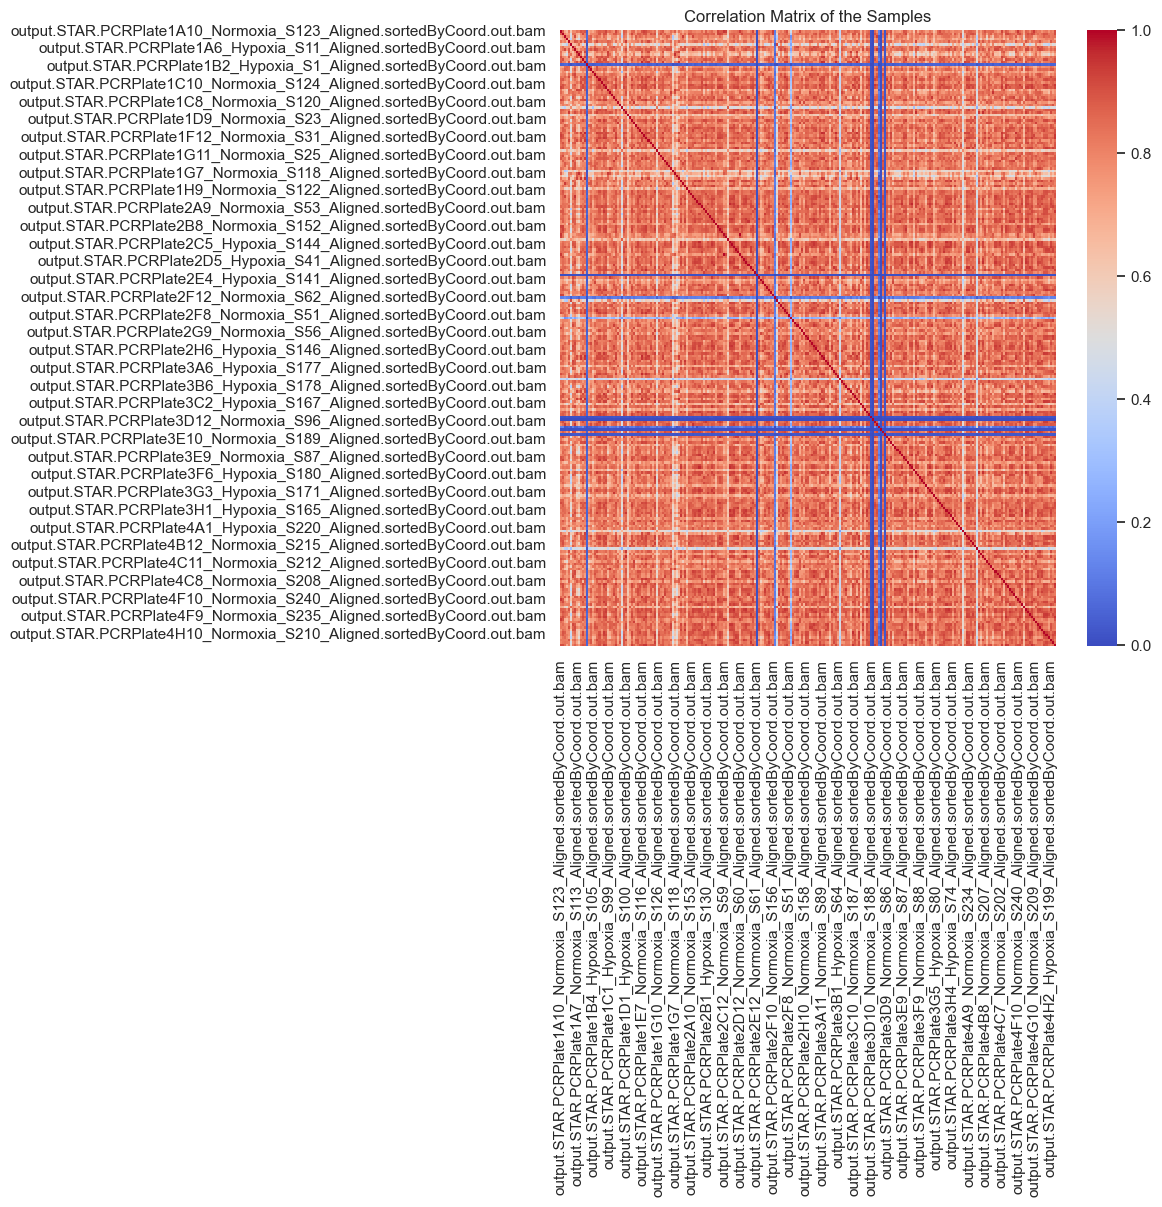

In [21]:
cell_corr_matrix = df_t.corr()
midpoint = (cell_corr_matrix.values.max() - cell_corr_matrix.values.min()) /2 + cell_corr_matrix.values.min()
print("Average correlation between cells: ", midpoint)
print("Minimum correlation between cells: ", cell_corr_matrix.values.min())
plt.figure(figsize=(8, 8))
sns.heatmap(cell_corr_matrix, cmap='coolwarm')
plt.title('Correlation Matrix of the Samples', fontsize=12)
plt.show()

We see that most samples have positively correlation values. The *Minimum correlation between cells* value of confirms that the correlation between cells is mostly positive.

This is expected because cells share many basic functions, so their gene expression profiles are often similar overall. However, some genes are activated only under specific conditions (such as low oxygen), which helps distinguish different cell states. Therefore, while some genes are consistently active in most cells because they are essential for survival, others remain inactive unless required in particular situations.

However, we can also see that there are some blue lines corresponding to cells with low correlation values with all other cells.

Let's visualize the previous plot only for some of the cells so we can select two cells with low correlation values with all others and two of them with high correlation values.

In [22]:
correlation_sum = cell_corr_matrix.sum(axis=1)
low_correlation_cells = correlation_sum.nsmallest(3)
print('Cells with the lowest correlation:\n',low_correlation_cells )
high_correlation_cells = correlation_sum.nlargest(3)
print('Cells with the highest correlation:\n',high_correlation_cells )

Cells with the lowest correlation:
 output.STAR.PCRPlate3D11_Normoxia_S92_Aligned.sortedByCoord.out.bam    1.332261
output.STAR.PCRPlate2E12_Normoxia_S61_Aligned.sortedByCoord.out.bam    3.182504
output.STAR.PCRPlate3D3_Hypoxia_S72_Aligned.sortedByCoord.out.bam      3.680432
dtype: float64
Cells with the highest correlation:
 output.STAR.PCRPlate4F5_Hypoxia_S229_Aligned.sortedByCoord.out.bam    201.396740
output.STAR.PCRPlate4F4_Hypoxia_S228_Aligned.sortedByCoord.out.bam    201.318144
output.STAR.PCRPlate2C6_Hypoxia_S46_Aligned.sortedByCoord.out.bam     200.659792
dtype: float64


Cell 1(output.STAR.PCRPlate3D11_Normoxia_S92_Aligned.sortedByCoord.out.bam): % of zero values: 99.85%

Cell 2(output.STAR.PCRPlate2E12_Normoxia_S61_Aligned.sortedByCoord.out.bam): % of zero values: 99.71%

Cell 3(output.STAR.PCRPlate3D3_Hypoxia_S72_Aligned.sortedByCoord.out.bam): % of zero values: 99.59%



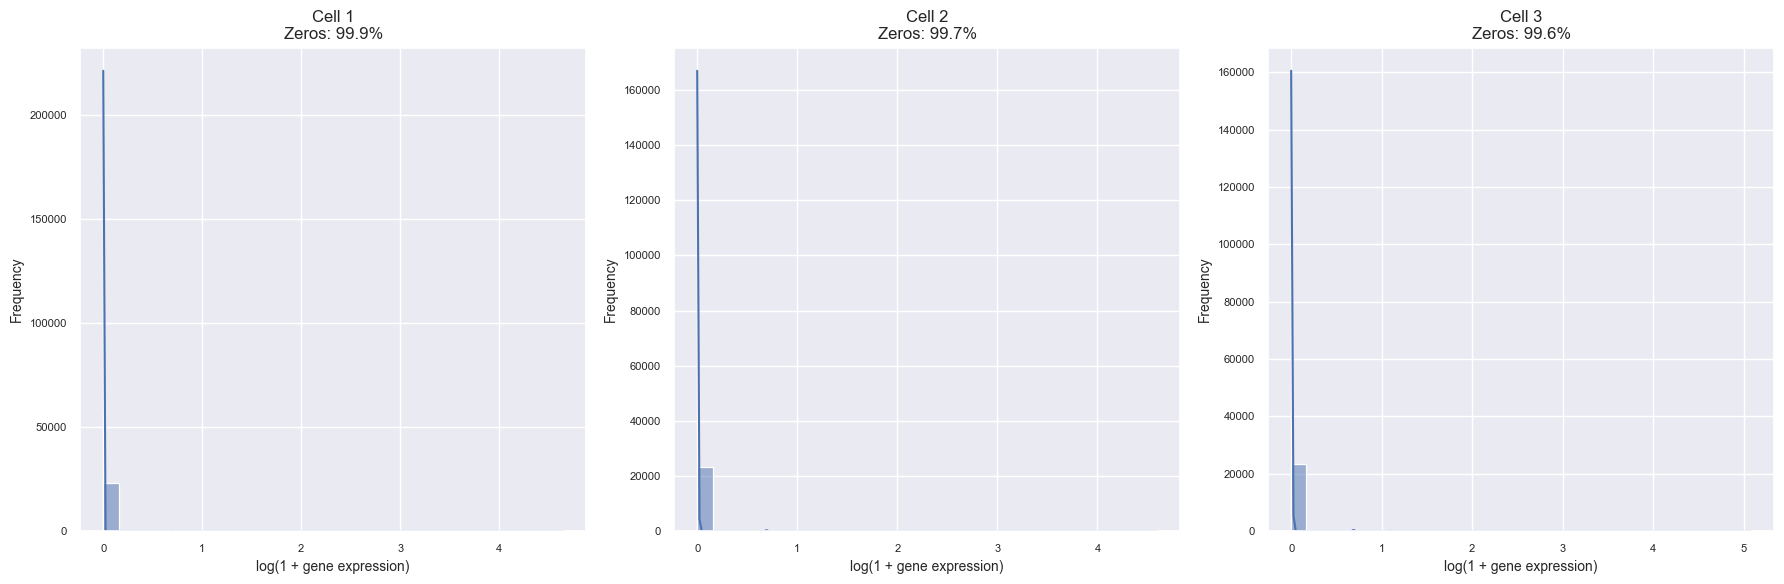

In [23]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for i, cell in enumerate(low_correlation_cells.index):
    zero_percentage = (df.loc[cell] == 0).mean() * 100
    print(f'Cell {i+1}({cell}): % of zero values: {zero_percentage:.2f}%\n')
    sns.histplot(np.log1p(df.loc[cell]),bins=30,kde=True,ax=axs[i])

    axs[i].set_title(f'Cell {i+1}\nZeros: {zero_percentage:.1f}%',)

    axs[i].set_xlabel('log(1 + gene expression)', fontsize=10)
    axs[i].set_ylabel('Frequency', fontsize=10)

    axs[i].tick_params(axis='both', labelsize=8)
    axs[i].grid(True)

plt.tight_layout()
plt.show()

Cell 1(output.STAR.PCRPlate4F5_Hypoxia_S229_Aligned.sortedByCoord.out.bam): % of zero values: 53.36%

Cell 2(output.STAR.PCRPlate4F4_Hypoxia_S228_Aligned.sortedByCoord.out.bam): % of zero values: 52.76%

Cell 3(output.STAR.PCRPlate2C6_Hypoxia_S46_Aligned.sortedByCoord.out.bam): % of zero values: 50.33%



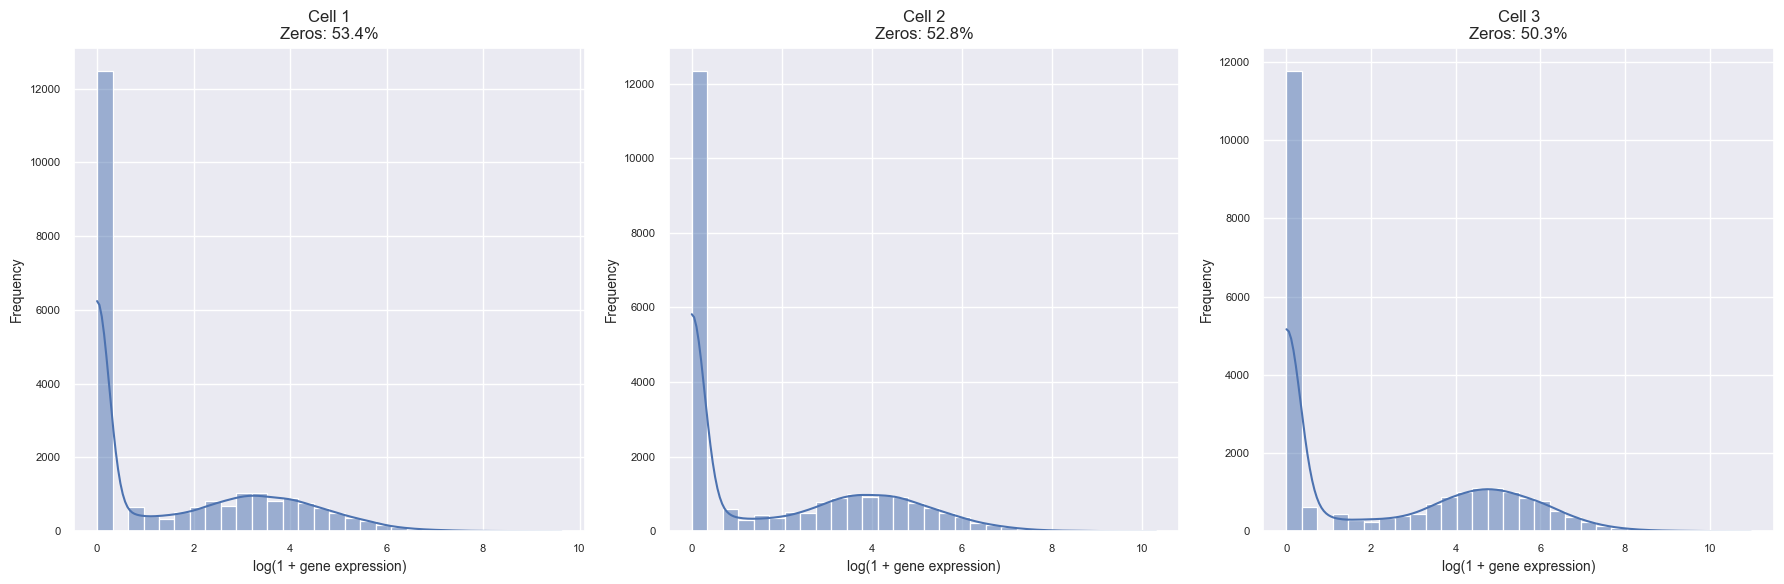

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for i, cell in enumerate(high_correlation_cells.index):
    zero_percentage = (df.loc[cell] == 0).mean() * 100
    print(f'Cell {i+1}({cell}): % of zero values: {zero_percentage:.2f}%\n')
    sns.histplot(np.log1p(df.loc[cell]),bins=30,kde=True,ax=axs[i])

    axs[i].set_title(f'Cell {i+1}\nZeros: {zero_percentage:.1f}%',)

    axs[i].set_xlabel('log(1 + gene expression)', fontsize=10)
    axs[i].set_ylabel('Frequency', fontsize=10)

    axs[i].tick_params(axis='both', labelsize=8)
    axs[i].grid(True)

plt.tight_layout()
plt.show()

So, the low correlated cells appear to be the ones that have almost all zero entries. This also means they can be characterized as low quality cells and will thus be handled in the Data Pre-Processing section. Meanwhile, the high correlated cells appear to be the ones with the least amount of zero-entries, and are thus the higher quality cells.

Overall, this prompts further investigation.

### **Outliers**

Studying outliers is important as it can greatly affect the results of our analyses and interpretations. If not appropriately handled, they could create serious issues such as skewing the data and impacting the mean, standard deviation, and correlations. In turn, this could alter the results of clustering, dimensionality reduction, and other future analyses.

As we have a sparse dataset, studying the outliers  becomes even more fundamental as they have an even larger impact on the statistical properties and interpretations of the data. Indeed, we expect that simply removing outliers would not work here, as many genes/features would be 0 if we excluded the outliers.

In this section, we'll try to identify the outliers and there are several methods to check them, such as:

- Visual tools
- IQR (Interquartile Range)

#### *Identifying Outliers (IQR)*


A standard approach to look for outliers is by calculating the Interquartile Range and using it to establish upper and lower bounds for the data, with any data point outside of it being considered an outlier. The IQR is defined as the difference between the third and first quartile, the values below which 25% and 75% of the data falls, respectively. 

We begin by looking for **outlier cells**:

In [25]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

WASH7P         0.0
CICP27         0.0
DDX11L17       0.0
WASH9P         0.0
OR4F29         0.0
             ...  
MT-TE         16.0
MT-CYB      1979.5
MT-TT         25.5
MT-TP         50.5
MAFIP          6.0
Length: 23396, dtype: float64


In [26]:
IQR.value_counts()

0.0       10145
1.0         700
2.0         330
3.0         225
4.0         181
          ...  
1528.5        1
370.5         1
635.5         1
278.0         1
1979.5        1
Name: count, Length: 1539, dtype: int64

We can see that several of the genes have an IQR of zero, which is expected given the indications that this is a very sparse dataset.

Let's continue by creating a new data set that excludes all the outlier cells.

In [27]:
df_noOut = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)]
print(df_noOut.shape)

(0, 23396)


We are left with an empty DataFrame. Clearly we should attempt to proceed with handling the outliers in another manner. 

We switch tactics by considering **outlier genes** instead of outlier cells: the matrix is transposed and the same steps performed above for the IQR are carried out.

In [28]:
Q1 = df_t.quantile(0.25)
Q3 = df_t.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam     51.0
output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam     125.0
output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam         5.0
output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam       40.0
output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam         22.0
                                                                        ...  
output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam     76.0
output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam     24.0
output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam       68.0
output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam      22.0
output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam      44.0
Length: 243, dtype: float64


Again, we attempt to create a new DataFrame without the outliers.

In [29]:
df_noOut_t = df_t[~((df_t < (Q1 - 1.5 * IQR)) |(df_t > (Q3 + 1.5 * IQR))).any(axis=1)]
df_noOut = df_noOut_t.T
print(df_noOut.shape)
print("Difference of number of columns:", df.shape[1]-df_noOut.shape[1])
print("Percentage of removed columns:", (df.shape[1]-df_noOut.shape[1])/df.shape[1]*100, "%")

(243, 10815)
Difference of number of columns: 12581
Percentage of removed columns: 53.774149427252524 %


This results in a DataFrame with 10790 genes, meaning around 53.77% were removed. This is an extremely large percentage.

It is important to take in the scientific context of our data. Outliers in this case should be treated very carefully as a sample expresses the RNA sequencing counts. It is normal for genes to have a very high expression in specific cells but near-zero expression in others. It is not an error as the IQR deems it, but an important biological signal. 

Next, we investigate how removing the outliers affects our results.

#### *Vizualizing Impact of Outliers:*

First, we recall the summary statistics of the distribution of our original DataFrame.

In [30]:
df_t.describe()

,output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A4_Hypoxia_S8_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A5_Hypoxia_S108_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A6_Hypoxia_S11_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A7_Normoxia_S113_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A8_Normoxia_S119_Aligned.sortedByCoord.out.bam,...,output.STAR.PCRPlate4G12_Normoxia_S243_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G2_Hypoxia_S198_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G7_Normoxia_S204_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam
count,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,...,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000,23396.000000
mean,99.565695,207.678278,9.694734,150.689007,35.700504,47.088434,152.799453,135.869422,38.363908,45.512139,...,76.361771,105.566593,54.026116,29.763806,28.905411,104.740725,35.181569,108.197940,37.279962,76.303855
std,529.532443,981.107905,65.546050,976.936548,205.885369,545.367706,864.974182,870.729740,265.062493,366.704721,...,346.659348,536.881574,344.068304,186.721266,135.474736,444.773045,170.872090,589.082268,181.398951,369.090274
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
75%,51.000000,125.000000,5.000000,40.000000,22.000000,17.000000,81.000000,76.000000,22.000000,18.000000,...,56.000000,67.000000,29.000000,18.000000,19.000000,76.000000,24.000000,68.000000,22.000000,44.000000
max,35477.000000,69068.000000,6351.000000,70206.000000,17326.000000,47442.000000,43081.000000,62813.000000,30240.000000,35450.000000,...,19629.000000,30987.000000,21894.000000,13457.000000,11488.000000,33462.000000,15403.000000,34478.000000,10921.000000,28532.000000


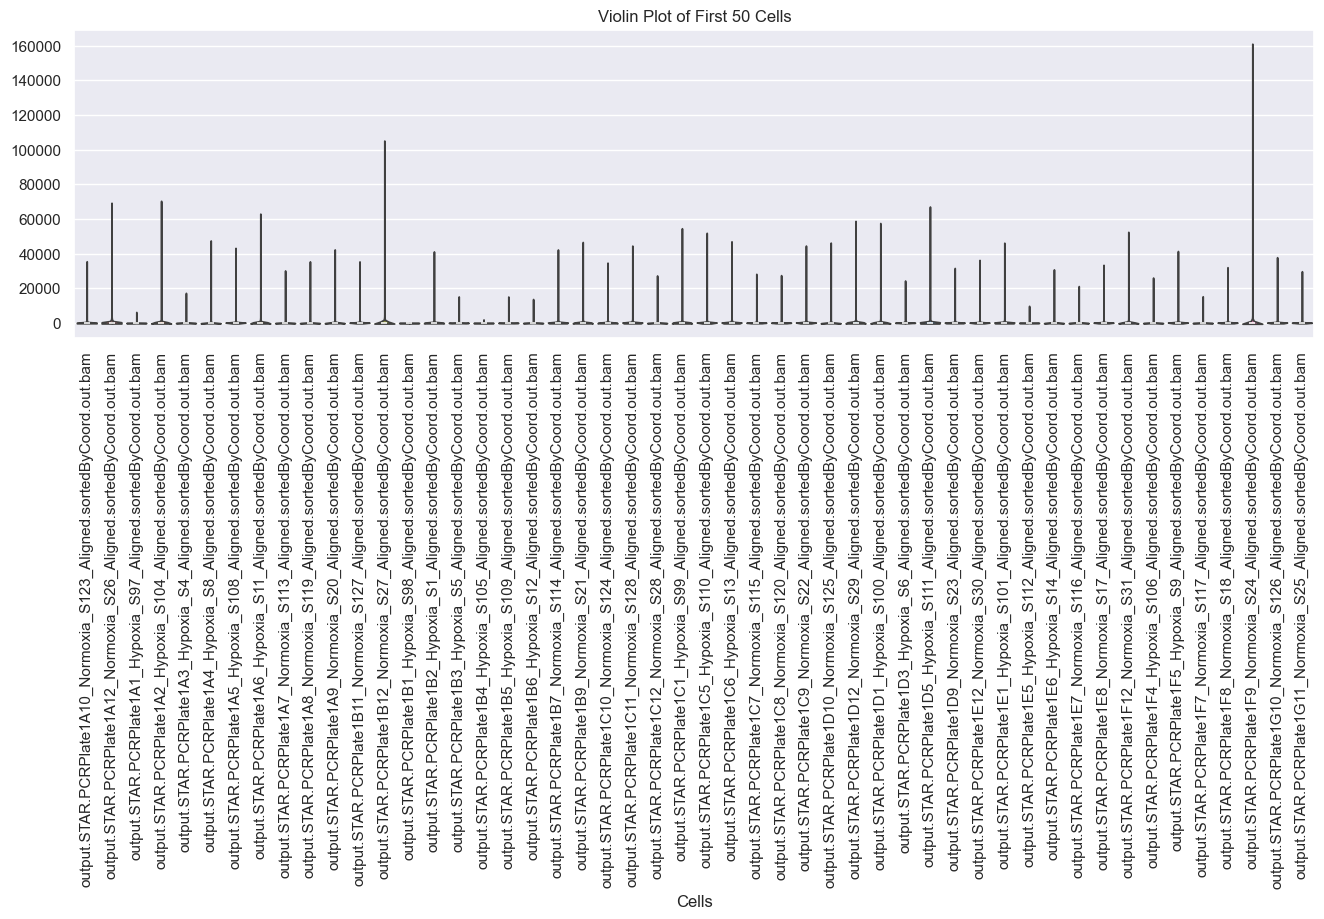

In [32]:
df_small = df_t.iloc[:, :50]
np.shape(df_small)
plt.figure(figsize=(16,4))
plot=sns.violinplot(data=df_small)
plt.title("Violin Plot of First 50 Cells")
plt.setp(plot.get_xticklabels(), rotation=90)
plt.xlabel("Cells")
plt.show()

Then, the same for the DataFrame without outliers:

In [33]:
df_noOut_t.describe()

,output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A4_Hypoxia_S8_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A5_Hypoxia_S108_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A6_Hypoxia_S11_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A7_Normoxia_S113_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A8_Normoxia_S119_Aligned.sortedByCoord.out.bam,...,output.STAR.PCRPlate4G12_Normoxia_S243_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G2_Hypoxia_S198_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G7_Normoxia_S204_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam
count,10815.00000,10815.000000,10815.000000,10815.000000,10815.000000,10815.000000,10815.000000,10815.000000,10815.000000,10815.000000,...,10815.000000,10815.000000,10815.000000,10815.000000,10815.000000,10815.000000,10815.000000,10815.000000,10815.000000,10815.000000
mean,1.49792,3.197873,0.167822,1.195099,0.649746,0.715118,2.379011,2.120388,0.564864,0.644290,...,1.558946,1.638927,0.885067,0.398151,0.450116,1.927878,0.749237,1.692094,0.492557,1.281923
std,6.46787,14.440975,0.764624,7.469947,3.005378,3.598585,13.057014,10.045234,2.949865,3.335927,...,6.309391,7.643547,4.265011,1.816472,2.083446,7.162205,3.101124,7.624975,2.276380,4.680917
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,103.00000,276.000000,12.000000,99.000000,55.000000,42.000000,196.000000,161.000000,49.000000,45.000000,...,107.000000,156.000000,71.000000,30.000000,32.000000,117.000000,50.000000,124.000000,42.000000,64.000000


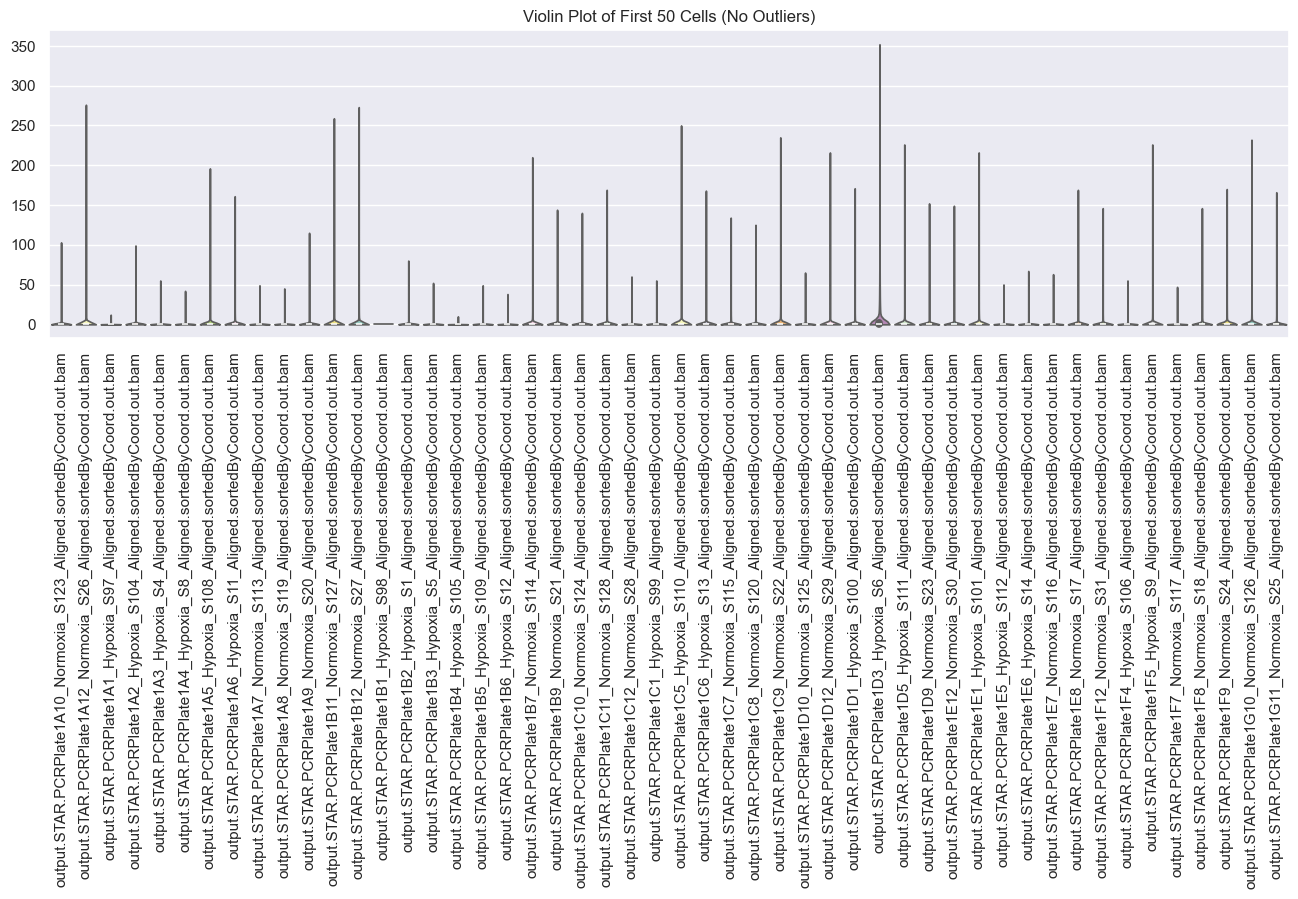

In [34]:
data_noOut_small = df_noOut.T.iloc[:, :50]
plt.figure(figsize=(16,4))

plot=sns.violinplot(data=data_noOut_small, palette="Set3", cut=0)
plt.title("Violin Plot of First 50 Cells (No Outliers)")
plt.setp(plot.get_xticklabels(), rotation=90)
plt.show()

The above plots and graphs show that once outliers are removed, the plots become much more compressed, with lower maxima and reduced spread, but most values are still concentrated at zero. This shows that outliers primarily influence the scale and dispersion of the data rather than its fundamental sparsity.

### **Sparsity**

As mentioned previously, it is standard for a Gene Expression Matrix to be characterized by a high degree of sparsity and we have seen hints of our dataset confirming to this. Thus, it prompts a more in-depth investigation. 

Sparsity refers to the amount of zero values in our data. To carry out our analysis, we will quantify sparsity by calculating it as the percentage of zero values in our dataframe.

In [35]:
total_elements = df.shape[0] * df.shape[1]
print("Total number of elements in the DataFrame:", total_elements)
zero_values = (df == 0).sum().sum()
print("Total number of zero values in the DataFrame:", zero_values)
sparsity = (zero_values / total_elements) * 100
print("Sparsity of the DataFrame: {:.2f}%".format(sparsity))

Total number of elements in the DataFrame: 5685228
Total number of zero values in the DataFrame: 3174951
Sparsity of the DataFrame: 55.85%


As expected, it appears to be a very sparse matrix. This is normal as gene expression matrices measure thousands of genes simutaneously. Given that only a fraction of these are active in any given sample, many entries end-up being  zero. As explained briefly earlier in the report, this occurs because gene activity depends on factors like cell type and conditions. This means that most genes are not expressed or are expressed at very low levels in many cells.

Next, to vizualize the sparsity of out data frame, we will create a boolean table to mark the location of the zero values and display it in a heatmap.

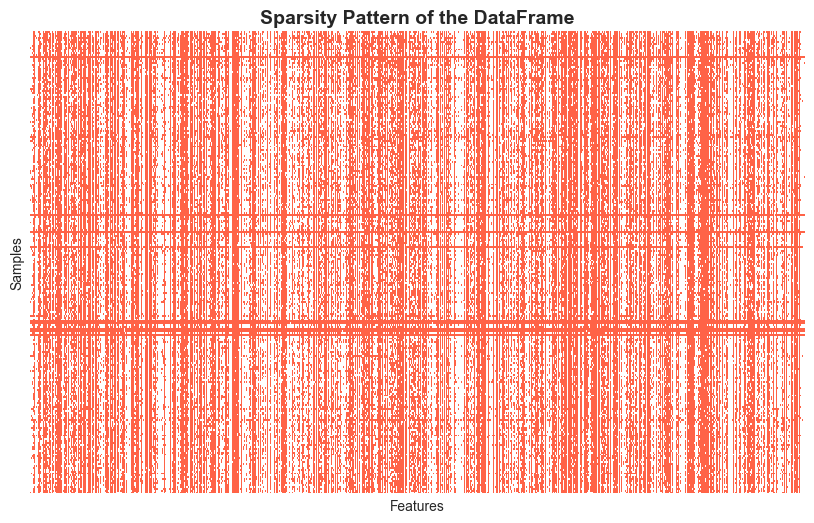

In [36]:
zero_mask = df == 0
colors = ["#FFFFFF", "#FF6347"] 
plt.figure(figsize=(10, 6))
sns.heatmap(zero_mask, cmap=sns.color_palette(colors), cbar=False, xticklabels=False, yticklabels=False)
plt.title('Sparsity Pattern of the DataFrame', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=10)
plt.ylabel('Samples', fontsize=10)
plt.show()

Indeed, the large presence of red entries (zero-values) in the heatmap puts it into perspective just how sparse the DataFrame is. 

Going back to our dataset without outliers:

In [37]:
total_elements_noOut = df_noOut.shape[0] * df_noOut.shape[1]
print("Total number of elements in the DataFrame without outliers:", total_elements_noOut)
zero_values_noOut = (df_noOut == 0).sum().sum()
print("Total number of zero values in the DataFrame without outliers:", zero_values_noOut)
sparsity_noOut = (zero_values_noOut / total_elements_noOut) * 100
print("Sparsity of the DataFrame without Outliers: {:.2f}%".format(sparsity_noOut))

Total number of elements in the DataFrame without outliers: 2628045
Total number of zero values in the DataFrame without outliers: 2279335
Sparsity of the DataFrame without Outliers: 86.73%


Indeed,we see that removing outliers led to many non-zero values being eliminated, leaving the data dominated by zeros. Given the scientific context of our study and the fact that non-zero entries represent genes being expressed, removing the outliers can distort the underlying structure and reduce our dataset's informativeness

On another note, sparse matrix representations typically only store the non-zero values in the matrix. This could be very advantageous for our analysis as it reduces memory usage and speeds up commputation. As a matter of fact, it is commonly used for gene expression analysis. However, it is not necessary, so we will continue without.

The sparsity of our data frame could be adressed by filtering out genes that are expressed in only a small number of cells or cells with too little detected gene expressions to be considered reliable. Also, normalization and log-transformation could be used to stabilize the data and make expression levels more comparable across cells. Then, dimensionality reduction techniques such as Principal Component Analysis (PCA) can be used to summarize the data while preserving the most relevant features and making it easier to carry out clustering. This will be carried out in the following sections.

### **Distribution of the Data**

We begin our analysis of the distribution of our data by plotting the distribution of the distribution of gene expression counts of 3 randomly chosen genes. 

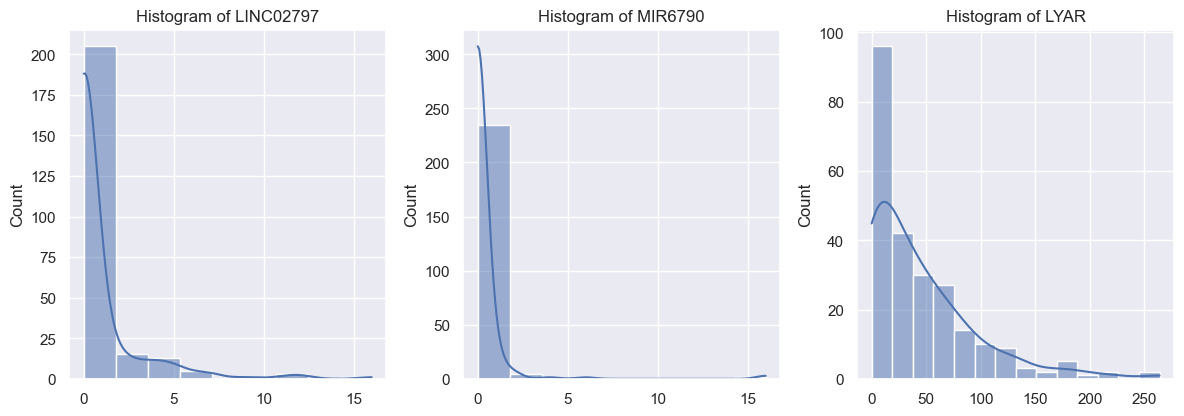

In [38]:
random_columns = np.random.choice(df.columns[1:], 3, replace=False)

fig = plt.figure(figsize=(12, 8))
for i, column in enumerate(random_columns):  
    plt.subplot(2, 3, i+1) 
    sns.histplot(df[column], kde=True)
    plt.title(f'Histogram of {column}', )
    plt.xlabel('')
    plt.grid(True)
plt.tight_layout()
plt.show()

This already gives us a notion that our data is highly assymetrical. Still, to further investigate this, we proceed with the skewness and kurtosis of these distributions for all the genes.

**Skewness** is a measure of symmetry. We will consider the skewness of our data by calculating how skewed each gene's data is, then plotting the distribution of those skewness values.

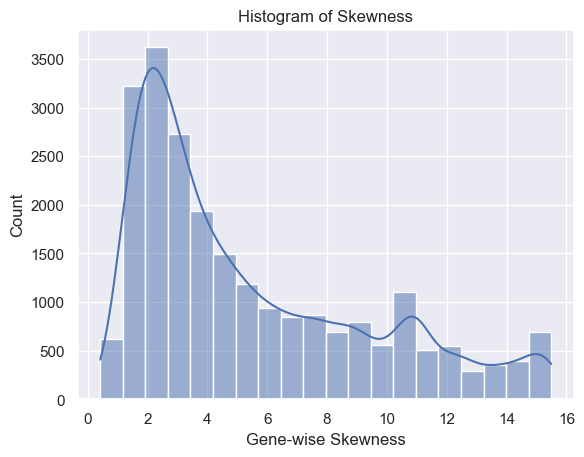

Mean Skewness: 5.47696879797724


In [39]:
skew_values =  [skew(df[col]) for col in df.columns]

sns.histplot(skew_values,kde=True, bins=20)
plt.title("Histogram of Skewness")
plt.xlabel("Gene-wise Skewness")
plt.show()
print("Mean Skewness:", np.mean(skew_values))


From the above histogram, we can see that the distribution of skewness values is positively skewed. This exemplifies how gene expression data is typically positively skewed due to most genes being lowly expressed or inactive, while a small number of genes show high expression levels.

**Kurtosis** describes the shape of a distribution's tails, identifying how often extreme outliers occur with respect to a normal distribution. Higher kurtosis means a higher frequency of extreme outliers, which is what we expect from our data considering the previous analysis conducted on the outliers in our data.

Similarly to the analysis of skewness, we will proceed by calculating the kurtosis for each gene's data and then plotting the distribution of those kurtosis values.

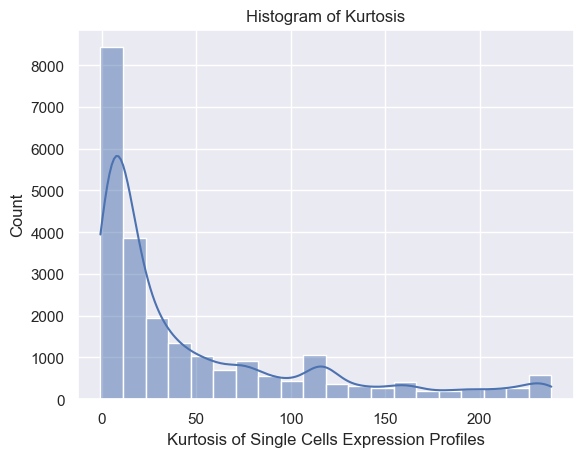

Mean Kurtosis: 49.840497906749114


In [40]:
kurt_values = [kurtosis(df[col]) for col in df.columns]

sns.histplot(kurt_values, kde=True, bins=20)
plt.title("Histogram of Kurtosis")
plt.xlabel("Kurtosis of Single Cells Expression Profiles")
plt.show()
print("Mean Kurtosis:", np.mean(kurt_values))


This histogram show that most of the genes have a positive kurtosis and in general, many gene expression distributions are heavy-tailed.

These confirm that the data deviate strongly from the Gaussian distribution and supports the need for preprocessing techniques such as log transformation and dimensionality reduction.

# **Data Pre-Processing**

## **Filtering**

### **Duplicate Genes**


We start by dropping the exact duplicates genes from our DataFrame that were identified in the Data Quality Check section of the Exploratory Data Analysis. 

In [41]:
df_t = df_t.drop_duplicates(inplace=False)
df = df_t.T

### **Quality Control**

As previously mentioned, we will now remove the low-quality cells based on the number of counts per cell and the number of detected genes per cell.

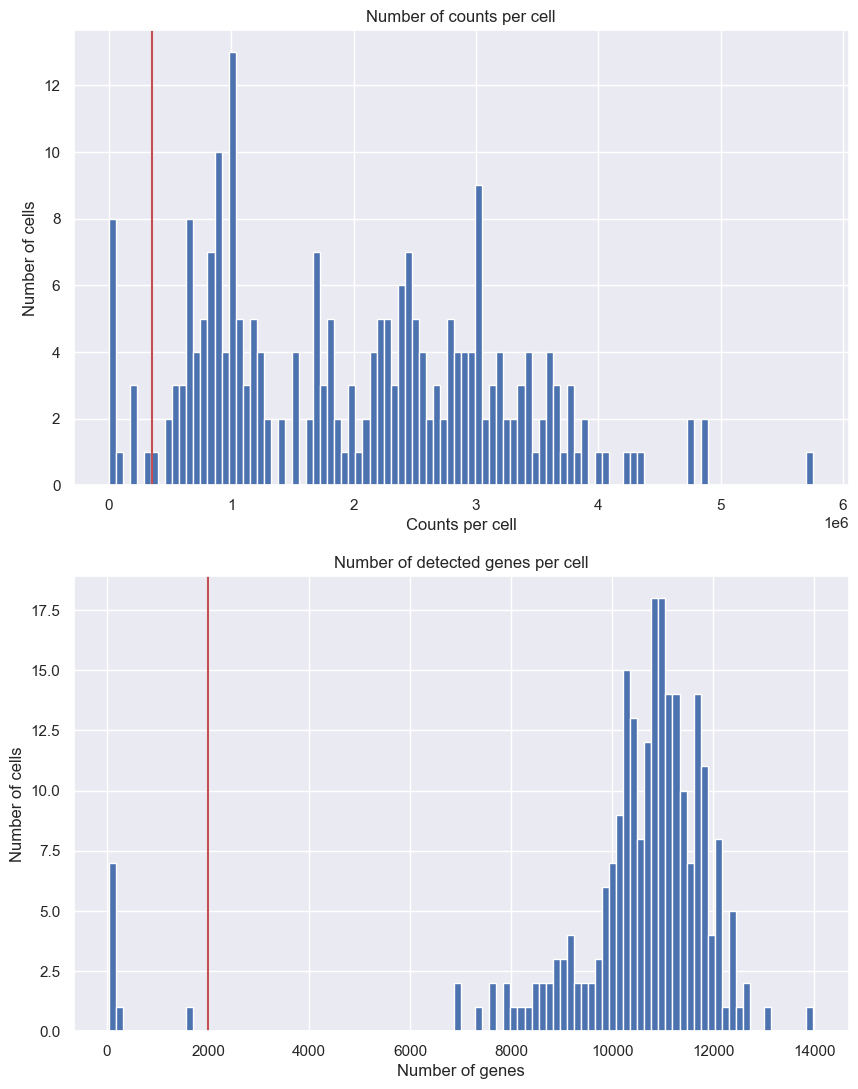

In [42]:
counts_per_cell = df_t.sum(axis = 0) 
number_of_genes = np.count_nonzero(df_t, axis=0)

counts_per_cell_threshold = 350000
number_of_genes_threshold = 2000

fig, ax = plt.subplots(2, 1, figsize = (10, 13))

ax[0].set_title("Number of counts per cell")
ax[0].hist(counts_per_cell, bins = 100)
ax[0].axvline(counts_per_cell_threshold, color = "r")
ax[0].set_xlabel("Counts per cell")
ax[0].set_ylabel("Number of cells")

ax[1].set_title("Number of detected genes per cell")
ax[1].hist(number_of_genes, bins = 100)
ax[1].axvline(number_of_genes_threshold, color = "r")
ax[1].set_xlabel("Number of genes")
ax[1].set_ylabel("Number of cells")
ax[1].grid(True)

plt.show()

Based on the quality control filtering and the visual inspection of the histrograms, we decided to put as thresholds 350000 total counts and 2000 detected-genes. That is because, the detected-genes graph showed a clear low-value tail separated from the main population, making it a reliable criterion. Although the counts-per-cell distribution exhibited a more gradual transition, it is still a good indicator of cell quality. These threshlods are considered heuristic rather than strictly optimal. So, the number of cells got reduced from 243 to 230. </p>

In [43]:
df_filtered = df_t.loc[:, (number_of_genes > number_of_genes_threshold) & (counts_per_cell > counts_per_cell_threshold)]
df_filtered

,output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A4_Hypoxia_S8_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A5_Hypoxia_S108_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A6_Hypoxia_S11_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A7_Normoxia_S113_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A8_Normoxia_S119_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A9_Normoxia_S20_Aligned.sortedByCoord.out.bam,...,output.STAR.PCRPlate4G12_Normoxia_S243_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G2_Hypoxia_S198_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G7_Normoxia_S204_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam
"""WASH7P""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""CICP27""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""DDX11L17""",0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
"""WASH9P""",0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,0
"""OR4F29""",2,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"""MT-TE""",22,43,0,0,3,47,4,2,8,17,...,24,15,15,4,4,26,1,4,4,20
"""MT-CYB""",4208,6491,4819,310,695,2885,1552,366,1829,3387,...,1119,1429,808,999,916,3719,984,2256,981,2039
"""MT-TT""",26,62,11,4,0,41,9,2,8,9,...,48,31,3,8,5,42,1,15,6,34
"""MT-TP""",66,71,3,9,14,91,22,3,30,37,...,119,52,11,22,15,48,18,36,8,79


In [44]:
filtered_meta = df_meta.loc[df_filtered.T.index]
print(filtered_meta["Condition"].value_counts())

Condition
Hypo     117
Normo    112
Name: count, dtype: int64


So, the dataset is still balanced after quality control.

## **Transformations**

To deal with the assymetry and high kurtosis of our data, we have many options for concave data transformations that will reduce the overdispersion of our data by compressing extreme values and stabilizing the variance.

We will try two of these: the *logarithmic transformation* and the *square-root transformation*

#### **Square-Root Transformation**

In [45]:
df_sqrt = np.sqrt(df_filtered)

skew_sqrt = [skew(df_sqrt[col]) for col in df_sqrt.columns]
kurt_sqrt = [kurtosis(df_sqrt[col]) for col in df_sqrt.columns]

mean_skewness_sqrt = np.mean(skew_sqrt)
mean_kurtosis_sqrt = np.mean(kurt_sqrt)

print(f"Mean skewness after square-root transformation: {mean_skewness_sqrt:.2f}")
print(f"Mean kurtosis after square-root transformation: {mean_kurtosis_sqrt:.2f}")

Mean skewness after square-root transformation: 4.16
Mean kurtosis after square-root transformation: 42.06


#### **Log Transformation**

In [46]:
df_log = np.log2(df_filtered+1)

skew_log = [skew(df_log[col]) for col in df_log.columns] 
kurt_log = [kurtosis(df_log[col]) for col in df_log.columns]

mean_skewness_log = np.mean(skew_log)
mean_kurtosis_log = np.mean(kurt_log)

print(f"Mean skewness after log transformation: {mean_skewness_log:.2f}")
print(f"Mean kurtosis after log transformation: {mean_kurtosis_log:.2f}")

Mean skewness after log transformation: 0.78
Mean kurtosis after log transformation: -0.81


Evidently, the log-transformation substantially improved the distribution of the gene expression data compared with the square-root transformation. The mean skewness and kurtosis after the log-transformation are closer to zero than after the square root transformation. Therefore, the log-transformed data more closely approximated a normal distribution and was considered more suitable for downstream analyses.

Let's visualize skewness and kurtosis of the transformed data:

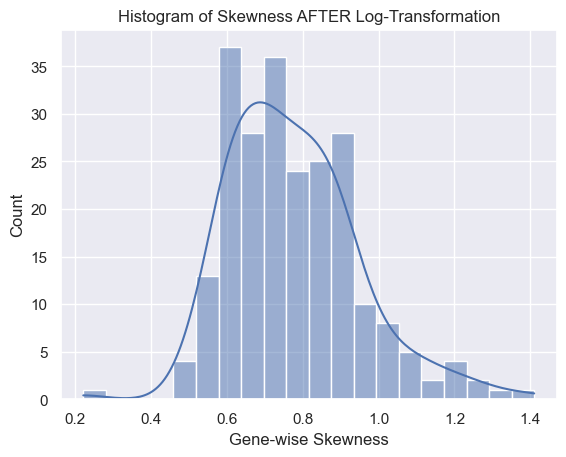

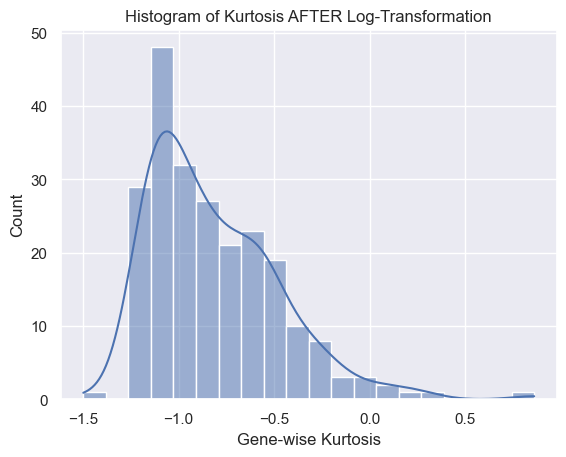

In [47]:
sns.histplot(skew_log, kde=True, bins=20)
plt.title("Histogram of Skewness AFTER Log-Transformation")
plt.xlabel("Gene-wise Skewness")
plt.show()

sns.histplot(kurt_log, kde=True, bins=20)
plt.title("Histogram of Kurtosis AFTER Log-Transformation")
plt.xlabel("Gene-wise Kurtosis")
plt.show()

We proceed by normalizing the original DataFrame and afterwards we will apply the log-transformation.

## **Normalizing**

We apply Counts Per Million (CPM) normalization, a standard technique for RNA-seq data. It works as follows: For each cell, gene counts are divided by the total number of reads in that cell and multiplied by one million. This normalization is performed across cells to correct the differences and make the gene expressions comparable between observations.

In [48]:
df_filt_normal = pd.DataFrame()
for column in df_filtered.columns:
    cpm = df_filtered[column] / df_filtered[column].sum() * 1e6
    df_filt_normal = pd.concat([df_filt_normal, cpm], axis=1)

df_filt_normal.head()

,output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A4_Hypoxia_S8_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A5_Hypoxia_S108_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A6_Hypoxia_S11_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A7_Normoxia_S113_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A8_Normoxia_S119_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A9_Normoxia_S20_Aligned.sortedByCoord.out.bam,...,output.STAR.PCRPlate4G12_Normoxia_S243_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G2_Hypoxia_S198_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G7_Normoxia_S204_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam
"""WASH7P""",0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
"""CICP27""",0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
"""DDX11L17""",0.000000,0.0,0.0,0.0,0.907705,0.000000,0.0,0.000000,0.0,0.529511,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
"""WASH9P""",0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,1.114129,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.408107,0.0,0.395047,0.0,0.0
"""OR4F29""",0.858577,0.0,0.0,0.0,0.000000,0.279729,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0


In [49]:
df_filt_normal.describe()

,output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A4_Hypoxia_S8_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A5_Hypoxia_S108_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A6_Hypoxia_S11_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A7_Normoxia_S113_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A8_Normoxia_S119_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A9_Normoxia_S20_Aligned.sortedByCoord.out.bam,...,output.STAR.PCRPlate4G12_Normoxia_S243_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G2_Hypoxia_S198_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G7_Normoxia_S204_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam
count,23342.000000,23342.000000,23342.000000,23342.000000,23342.000000,23342.000000,23342.000000,23342.000000,23342.000000,23342.000000,...,23342.000000,23342.000000,23342.000000,23342.000000,23342.000000,23342.000000,23342.000000,23342.000000,23342.000000,23342.000000
mean,42.841230,42.841230,42.841230,42.841230,42.841230,42.841230,42.841230,42.841230,42.841230,42.841230,...,42.841230,42.841230,42.841230,42.841230,42.841230,42.841230,42.841230,42.841230,42.841230,42.841230
std,227.575576,202.177123,277.479597,246.797629,495.601261,242.229330,274.228996,295.648099,344.781681,236.931090,...,194.261551,217.646833,272.544534,268.473331,200.581456,181.713738,207.824099,232.975426,208.237751,206.999688
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.529511,...,0.559765,0.000000,0.000000,0.000000,0.000000,0.816214,0.000000,0.000000,0.000000,0.560216
75%,22.322990,25.936076,11.348368,26.342100,15.430992,22.937775,23.908589,24.510842,16.904647,30.182141,...,31.906586,27.130921,23.736881,25.851743,28.099900,31.016117,29.157848,26.863211,26.373636,25.209703
max,15229.860262,14217.086605,19918.087482,20745.601169,43063.360561,12051.003542,19760.133938,33691.265896,33292.762182,22403.621010,...,10987.620804,12547.848619,17323.176058,19327.050402,16990.086651,13656.069630,18713.264148,13620.437847,12522.890596,15984.071950


As stated previously, we apply the log-transformation to the normalized data.

In [50]:
df_filt_normal_log = np.log2(df_filt_normal+1)
df_filt_normal_log

,output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A4_Hypoxia_S8_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A5_Hypoxia_S108_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A6_Hypoxia_S11_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A7_Normoxia_S113_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A8_Normoxia_S119_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1A9_Normoxia_S20_Aligned.sortedByCoord.out.bam,...,output.STAR.PCRPlate4G12_Normoxia_S243_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G2_Hypoxia_S198_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G7_Normoxia_S204_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam
"""WASH7P""",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"""CICP27""",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"""DDX11L17""",0.000000,0.000000,0.000000,0.000000,0.931838,0.000000,0.000000,0.000000,0.000000,0.613071,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"""WASH9P""",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.080064,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.493757,0.000000,0.480314,0.000000,0.000000
"""OR4F29""",0.894198,0.000000,0.000000,0.000000,0.000000,0.355838,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"""MT-TE""",3.384650,3.300300,0.000000,0.000000,1.896511,3.822451,1.175267,1.690756,3.089697,3.322172,...,3.851434,2.822544,3.685765,2.753782,2.789890,3.537393,1.147248,1.367477,2.482001,3.609319
"""MT-CYB""",10.819736,10.384913,10.418058,8.539873,9.303450,9.658244,8.934394,8.675150,10.747102,10.809330,...,9.293188,9.179058,9.322634,10.487611,10.404834,10.568668,10.224571,9.801266,10.136854,10.158963
"""MT-TT""",3.604249,3.782639,2.042925,2.533432,0.000000,3.640261,1.937827,1.690756,3.089697,2.527471,...,4.800574,3.760552,1.754327,3.642663,3.069481,4.181141,1.147248,2.791962,2.978210,4.325338
"""MT-TP""",4.874454,3.964840,0.888404,3.557816,3.776933,4.725487,2.985666,2.118488,4.866632,4.364006,...,6.079207,4.463154,3.278509,5.026648,4.535066,4.363811,4.515283,3.928058,3.346736,5.500070


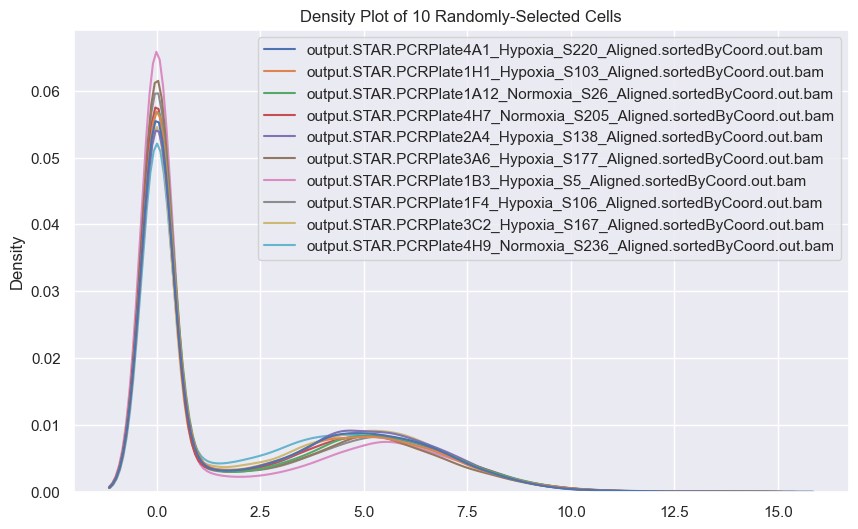

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))
random_columns = np.random.choice(df_filt_normal_log.columns[1:], 10, replace=False)

sns.kdeplot(df_filt_normal_log[random_columns], ax=ax)
ax.set_title("Density Plot of 10 Randomly-Selected Cells")
ax.set_xlabel("")
ax.grid(True)
plt.show()

The density plots of 10 cells from the log-transformed CPM-normalized data show a bimodal distribtuion. There is a sharp near near 0, indicating that a large number of genes are either not expressed or expressed at extremely low levels in each cell. There is also a second peak around 5, correspoding to genes that are actively expressed. The presence of this second peak suggests that the majority of the genes have comparable expression levels across cells after the normalization and log-transformation.

Compared to the raw data, the distributions now are more balanced and less skewed. Extreme values are compressed, reducing the influence of highly expressed genes, while preserving the biological structure of this data.

## **Feature selection**

There are several genes that are expressed at very low levels or remain almost constant across cells, making them less useful for disinguishing the two biological conditions. Thus, to finalize the Data Pre-Processing section of this analysis, we perform highly variable gene (HVG) selection as to retain the 3000 genes that contain the most biologically information variability across cells.

First, we cleaned the names of the genes to ensure consistency between our dataset and the filtered and normalised provided. For each gene, we computed the mean expression across cells and the variance across cells.  Since highly expressed genes naturally tend to have larger variances, we calculated the dispersion, defined as the division between variance over mean. This allows variability to be evaluated relative to the average expression level of each gene.

The genes were then ranked according to their normalized variability, and the top 3000 genes with the highest log-dispersion values were selected as highly variable genes.



In [52]:
gene_means = df_filt_normal_log.mean(axis=1)
gene_vars = df_filt_normal_log.var(axis=1)

dispersion = gene_vars / gene_means

In [53]:
dispersion.sort_values(ascending=False).head(3000)

"CEACAM5"      8.701602
"KRT13"        8.190506
"CEACAM6"      7.808625
"OASL"         7.672921
"KRT4"         7.257532
                 ...   
"LZTR1"        2.942049
"ZNF669"       2.942027
"GPR176-DT"    2.941720
"GPR19"        2.941616
"BEND3P3"      2.941135
Length: 3000, dtype: float64

In [54]:
top3000_genes = dispersion.sort_values(ascending=False).head(3000).index
df_filt_normal_log_3000 = df_filt_normal_log.T[top3000_genes]
print("Dimensionality of DataFrame after feature selection:", df_filt_normal_log_3000.shape)
df_filt_normal_log_3000.head()

Dimensionality of DataFrame after feature selection: (229, 3000)


,"""CEACAM5""","""KRT13""","""CEACAM6""","""OASL""","""KRT4""","""SPRR1B""","""SPINK1""","""CYP1B1""","""SYNPO2L""","""RSAD2""",...,"""SND1-IT1""","""DDIT4L""","""SIAH3""","""ARNTL""","""SRMP2""","""LZTR1""","""ZNF669""","""GPR176-DT""","""GPR19""","""BEND3P3"""
output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,3.838744,0.0,3.794795,0.000000,0.0
output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,5.265408,0.0,0.000000,0.000000,0.0
output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,7.096944,0.0,0.000000,0.000000,0.0
output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,3.229830,0.0,0.0,0.0,5.539159,0.0,0.000000,3.824875,0.0
output.STAR.PCRPlate1A4_Hypoxia_S8_Aligned.sortedByCoord.out.bam,0.0,11.867359,11.473211,0.0,6.416445,0.0,0.0,9.625336,0.0,0.0,...,0.0,4.510008,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0


### **Comparison with the Pre-Processed Dataset Provided**


Lastly, the selected genes were compared with the genes contained in the professor's filtered and normalized dataset. 

In [55]:
prof = pd.read_csv("/Users/bianca/Desktop/HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt",delimiter="\ ",engine='python',index_col=0)
common_genes = set(df_filt_normal_log_3000.columns).intersection(set(prof.index))
print("Common genes:", len(common_genes))
print("Percentage overlap:", len(common_genes)/3000 * 100)

Common genes: 1830
Percentage overlap: 61.0


The overlap between our dataset and the professor's is satisfyingly high, with around 61% of gene correspondence. Thus, it is reasonable to conclude that our analysis was in the right path.

In [57]:
# saving dataset
df_filt_normal_log_3000.to_csv("/Users/bianca/Desktop/final-dataset-SmartSeq-HCC1806.csv")